# SNN Hackathon 2026 – MNE-Python Preprocessing Tutorial
## Day 2: Bad Channels · ICA · Re-referencing · Epochs · Baseline · Rejection · ERP
 
---

---
## 0 · Imports & Setup

In [302]:
import os
import os.path as op
import mne
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mne.preprocessing import ICA, create_eog_epochs
 
mne.set_log_level('WARNING')  # suppress info messages, keep warnings
%matplotlib widget
mne.viz.set_browser_backend('matplotlib')
 
print('MNE version:', mne.__version__)

MNE version: 1.11.0


## 0.1 · Paths & participant

In [303]:
# Paths & participant ID
sub_id    = 'sub-4'
DATA_DIR  = f'../data/hackathon_data/derivatives/{sub_id}/eeg'
DATA_DIR_ORIG = f'../data/hackathon_data/{sub_id}/eeg'


# Path to the preprocessed file from Day 1 (filtered + resampled)
raw_filt_path = op.join(DATA_DIR, f'{sub_id}_filtered_raw.fif')

# Path to the original BrainVision file (needed for montage lookup)
raw_orig_path = op.join(DATA_DIR_ORIG, f'{sub_id}_task-gonogo.vhdr')

# Output directory
data_path = DATA_DIR

print(f'Participant: {sub_id}')
print(f'File: {raw_filt_path}')

# Load the preprocessed (filtered + resampled) data from Day 1
raw_orig = mne.io.read_raw_brainvision(raw_orig_path, preload=True)
raw_filtered = mne.io.read_raw_fif(raw_filt_path, preload=True)
print(raw_orig.info)
print(raw_filtered.info)

Participant: sub-4
File: ../data/hackathon_data/derivatives/sub-4/eeg\sub-4_filtered_raw.fif
<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, F9, FC5, FC1, C3, T7, CP5, CP1, Pz, P3, P7, P9, ...
 chs: 63 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 140.0 Hz
 meas_date: 2026-03-28 10:54:45 UTC
 nchan: 63
 projs: []
 sfreq: 500.0 Hz
>
<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, F9, FC5, FC1, C3, T7, CP5, CP1, Pz, P3, P7, P9, ...
 chs: 63 EEG
 custom_ref_applied: False
 file_id: 4 items (dict)
 highpass: 0.2 Hz
 lowpass: 40.0 Hz
 meas_date: 2026-03-28 10:54:45 UTC
 meas_id: 4 items (dict)
 nchan: 63
 projs: []
 sfreq: 256.0 Hz
>


## Part 0.2 · Mark Bad Channels

In [304]:
# Set montage & interpolate bad channels
# Set electrode positions; needed for interpolation and topographic plots
montage = mne.channels.make_standard_montage('standard_1020')
raw_orig.set_montage(montage, on_missing='ignore')
raw_filtered.set_montage(montage, on_missing='ignore')

raw_orig.info['bads'].extend(['P10','AF7', 'Fp2', 'Fp1', 'AF4', 'AF8'])
raw_filtered.info['bads'].extend(['P10','AF7', 'Fp2', 'Fp1', 'AF4', 'AF8'])
print(raw_orig.info)

'''
Suggestions for channels to remove per participant
'sub-1': ['P10'],                                     
'sub-2': ['P10', 'AF8', 'AF7', 'Fp2', 'Fp1'],       
'sub-3': ['F8', 'F10', 'AF8', 'AF7', 'Fp2', 'Fp1'], 
'sub-4': ['P10','AF7', 'Fp2', 'Fp1', 'AF4'],                   

'''

<Info | 9 non-empty values
 bads: 6 items (P10, AF7, Fp2, Fp1, AF4, AF8)
 ch_names: Fp1, Fz, F3, F7, F9, FC5, FC1, C3, T7, CP5, CP1, Pz, P3, P7, P9, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.0 Hz
 lowpass: 140.0 Hz
 meas_date: 2026-03-28 10:54:45 UTC
 nchan: 63
 projs: []
 sfreq: 500.0 Hz
>


"\nSuggestions for channels to remove per participant\n'sub-1': ['P10'],                                     \n'sub-2': ['P10', 'AF8', 'AF7', 'Fp2', 'Fp1'],       \n'sub-3': ['F8', 'F10', 'AF8', 'AF7', 'Fp2', 'Fp1'], \n'sub-4': ['P10','AF7', 'Fp2', 'Fp1', 'AF4'],                   \n\n"

---
## Part 1 · ICA – Artifact Correction on Continuous Data

### 📌 Task 1.1 – Prepare the 1 Hz high-pass copy for ICA fitting

In [305]:
#ICA on continuous data 
# Create a 1 Hz high-pass filtered COPY — only used for ica.fit().
# The higher cutoff produces more stable ICA weights by removing
# slow drifts that would otherwise dominate the decomposition.
raw_ica = raw_orig.copy().filter(l_freq=1.0, h_freq=None)
print(raw_ica.info)


<Info | 9 non-empty values
 bads: 6 items (P10, AF7, Fp2, Fp1, AF4, AF8)
 ch_names: Fp1, Fz, F3, F7, F9, FC5, FC1, C3, T7, CP5, CP1, Pz, P3, P7, P9, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 1.0 Hz
 lowpass: 140.0 Hz
 meas_date: 2026-03-28 10:54:45 UTC
 nchan: 63
 projs: []
 sfreq: 500.0 Hz
>


### 📌 Task 1.2 – Initialise and fit ICA

In [306]:
ica = ICA(n_components=12, max_iter='auto', random_state=17)
ica.fit(raw_ica)

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,45 iterations on raw data (350630 samples)
ICA components,12
Available PCA components,57
Channel types,eeg
ICA components marked for exclusion,—


### 📌 Task 1.3 – Inspect components visually

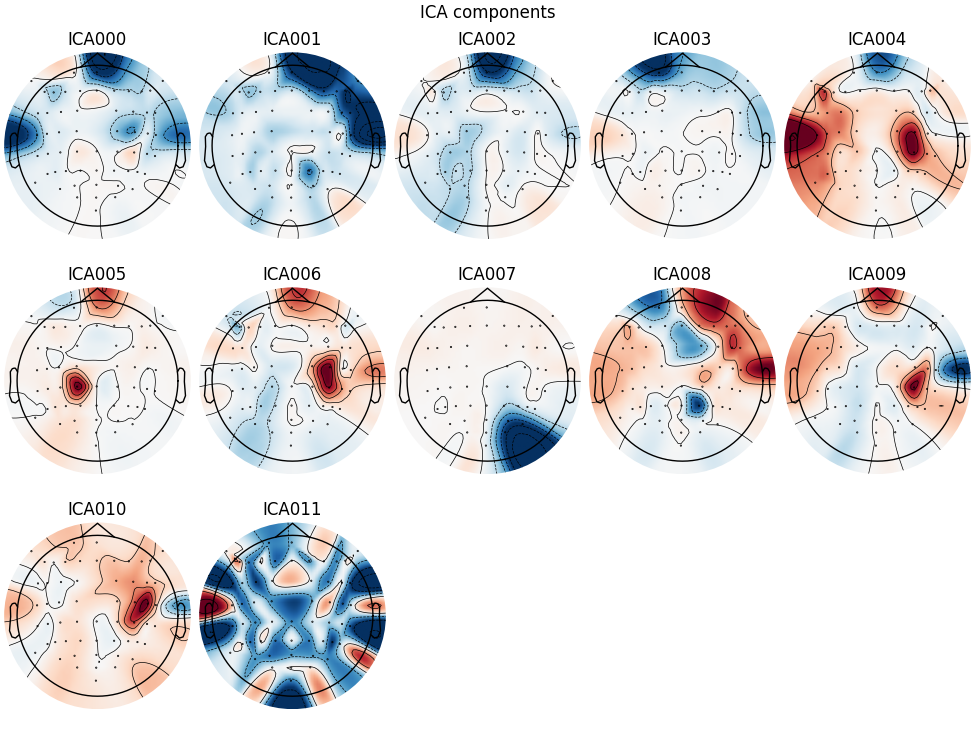

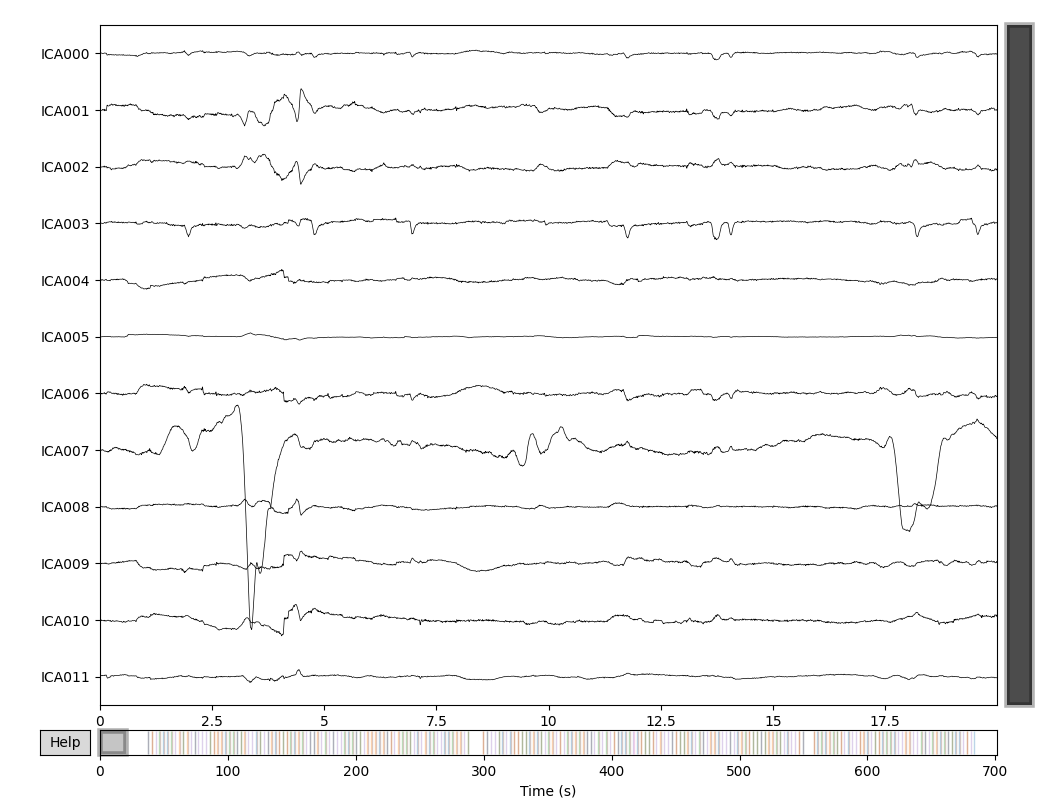

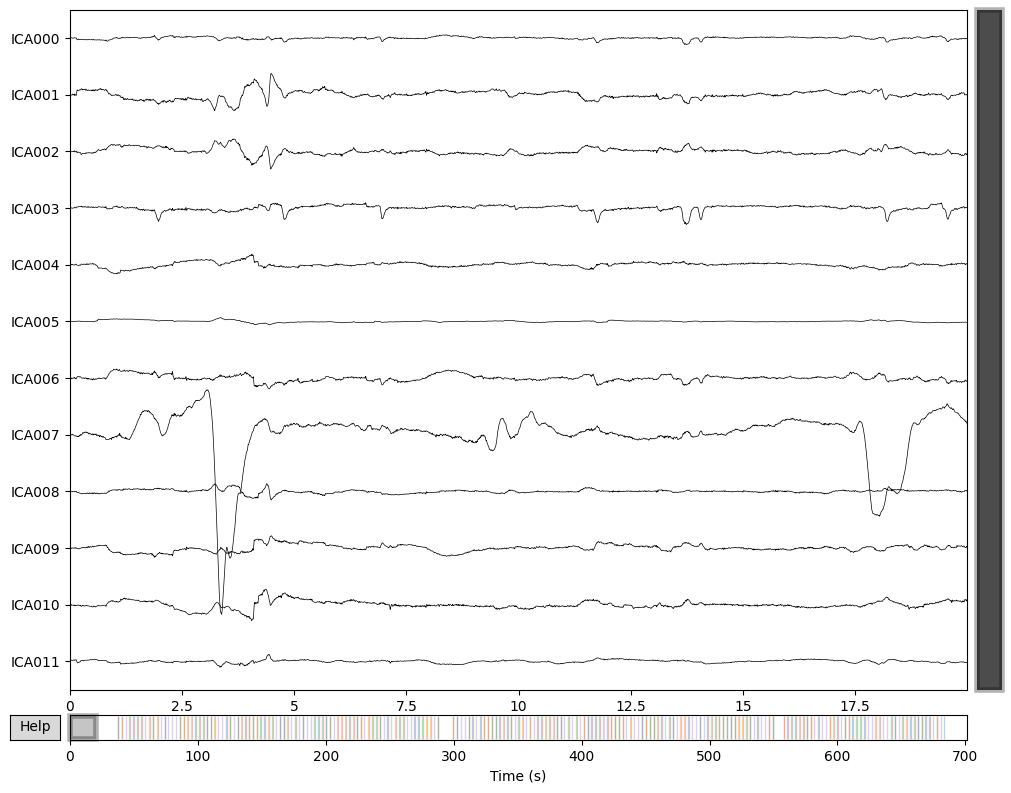

In [307]:
# Topographic maps of all components
ica.plot_components()

# Time-series of each component — plotted on the real (non-1-Hz) data
ica.plot_sources(raw_filtered)

### 📌 Task 1.4 – Find and exclude artifact components &  Preview: plot_overlay

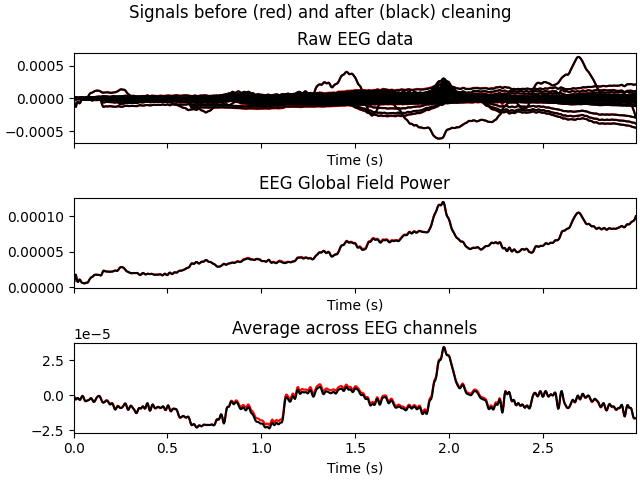

In [308]:
bad_components = [6] #put the index of components you want to exclude here

# Overlay: red = before, black = after artifact removal
ica.plot_overlay(raw_filtered, exclude=bad_components , picks='eeg'); 


### 📌 Task 1.6 – Apply ICA to the data

In [309]:
# Apply ICA to a COPY of the real data (not the 1-Hz copy)
raw_clean = ica.apply(raw_filtered.copy(), exclude=bad_components)

---
## Part 2 · Re-referencing

### 📌 Task 2.1 – Apply average reference

In [310]:
# Re-referencing (average reference) 
# Apply average reference AFTER ICA so the artifact components are
# not spread across all channels before decomposition.
raw_clean.set_eeg_reference(ref_channels='average')
raw_clean.apply_proj()

# check: raw_clean.info['projs'] should show the projection was applied

<Raw | sub-4_filtered_raw.fif, 63 x 179523 (701.3 s), ~86.4 MiB, data loaded>

### 📌 Task 2.2 – Butterfly plots: before vs after

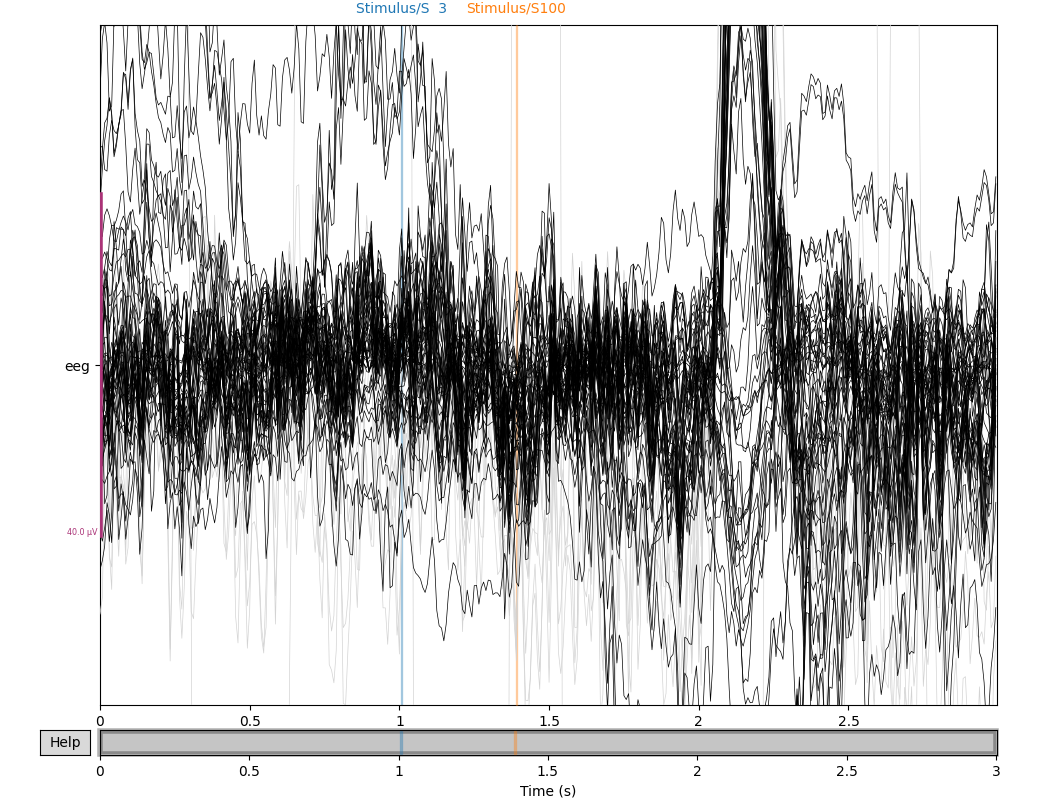

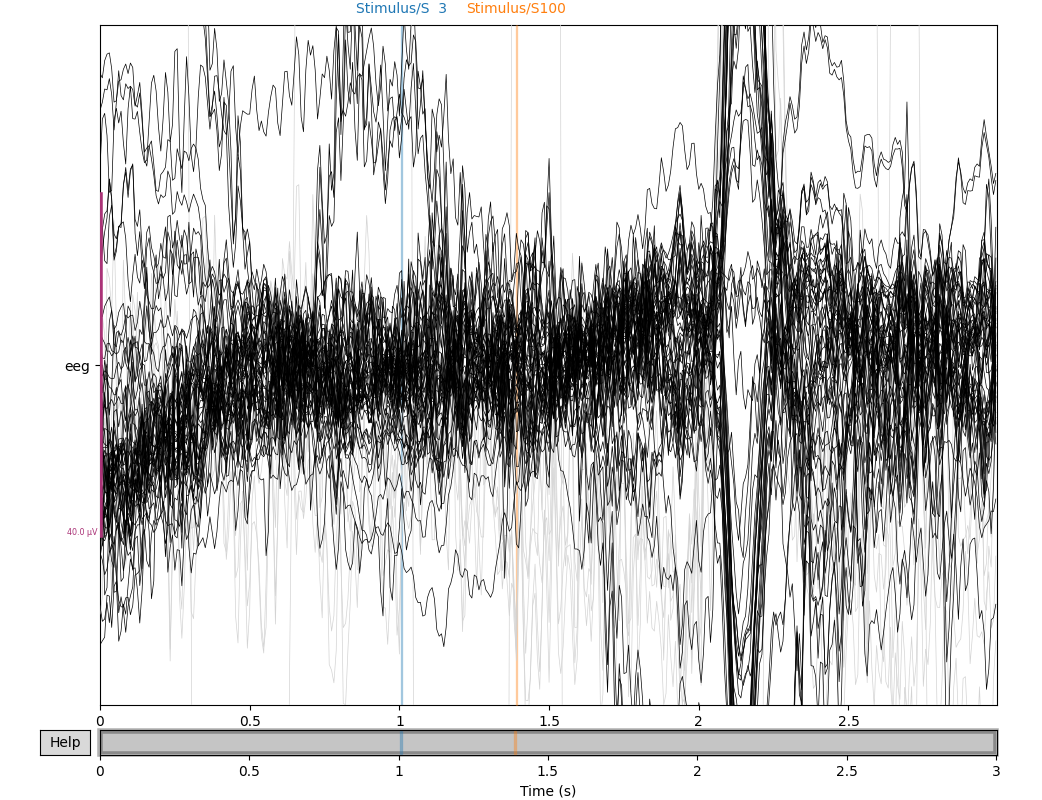

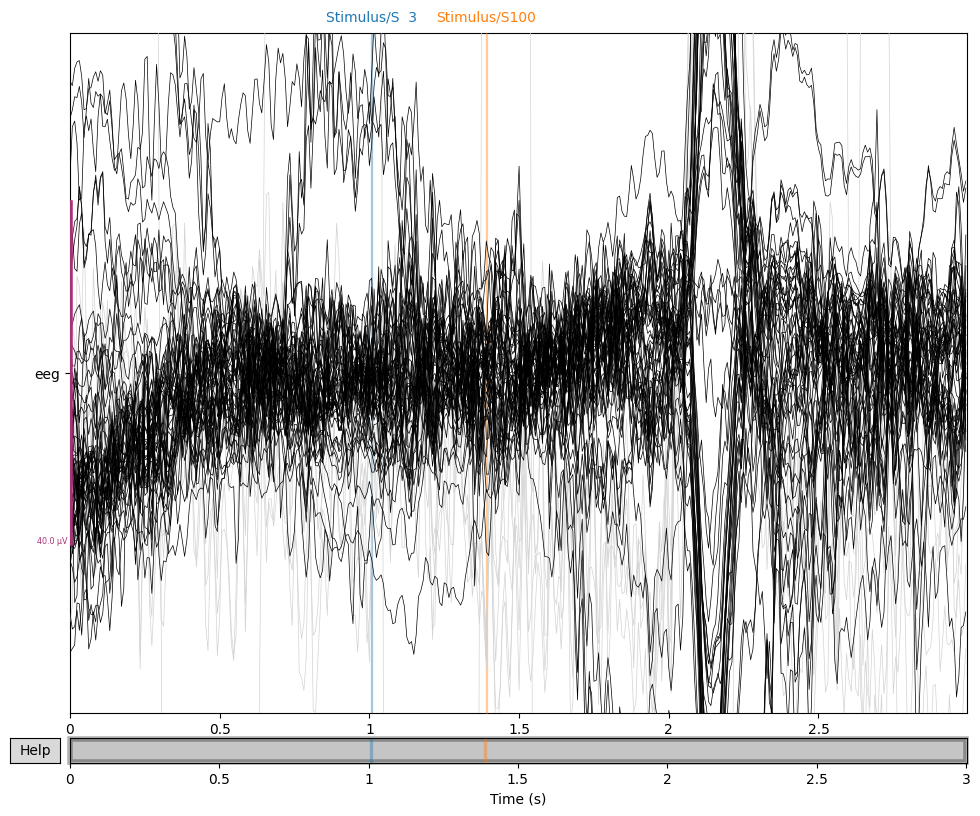

In [311]:
# Optional: butterfly comparison before vs. after re-referencing
raw_before_ref = ica.apply(raw_filtered.copy(), exclude=bad_components)  # no avg ref
raw_before_snippet = raw_before_ref.copy().crop(tmin=100, tmax=103)
raw_ref_snippet  = raw_clean.copy().crop(tmin=100, tmax=103)

raw_before_snippet.plot(butterfly=True, title='Before re-reference')
raw_ref_snippet.plot(butterfly=True, title='After average reference')

---
## Part 3 · Bad Channel Interolation

In [312]:
raw_filtered.interpolate_bads(reset_bads=True, method = 'spline')

<Raw | sub-4_filtered_raw.fif, 63 x 179523 (701.3 s), ~86.4 MiB, data loaded>

---
## Part 4 · Extract Epochs

### 📌 Task 4.1 – Find events

In [313]:
# Extract events 
events, event_id = mne.events_from_annotations(raw_clean)

print(event_id)
print(f'\nTotal events: {len(events)}')
print('\nFirst 10 rows (sample, 0, event_code):')
print(events[:10])

{np.str_('Stimulus/S  1'): 1, np.str_('Stimulus/S  2'): 2, np.str_('Stimulus/S  3'): 3, np.str_('Stimulus/S  4'): 4, np.str_('Stimulus/S100'): 100, np.str_('Stimulus/S200'): 200}

Total events: 369

First 10 rows (sample, 0, event_code):
[[ 9560     0     1]
 [ 9657     0   100]
 [10335     0     2]
 [10434     0   100]
 [11133     0     4]
 [11897     0     3]
 [11982     0   100]
 [12661     0     1]
 [12771     0   100]
 [13454     0     1]]


### 📌 Task 4.2 – Create epochs

In [314]:
# Extract Epochs (time-lock to stimulus onset) 
###NOTE: Adjust event_id_select to match the trigger codes sent by PsychoPy.
# Check the output of event_id above to verify which codes map to Go and NoGo.
# Triggers 1, 2, 3 = Go stimuli; Trigger 4 = NoGo stimulus.
# Use hierarchical naming (Go/1, Go/2, Go/3) so that epochs['Go']
# automatically selects all three sub-conditions.
event_id_select = {'Go/1': 1, 'Go/2': 2, 'Go/3': 3, 'NoGo': 4}

epochs = mne.Epochs(
    raw_clean, events, event_id=event_id_select,
    tmin=-0.1, tmax=0.6,
    baseline=None, preload=True, verbose=False
)

print(epochs)
print(f'\nGo:   {len(epochs["Go"])} epochs')
print(f'NoGo: {len(epochs["NoGo"])} epochs')

<Epochs | 211 events (all good), -0.102 – 0.602 s (baseline off), ~18.4 MiB, data loaded,
 'Go/1': 54
 'Go/2': 52
 'Go/3': 52
 'NoGo': 53>

Go:   158 epochs
NoGo: 53 epochs


### 📌 Task 4.3 – (Bonus) Epoch image plot

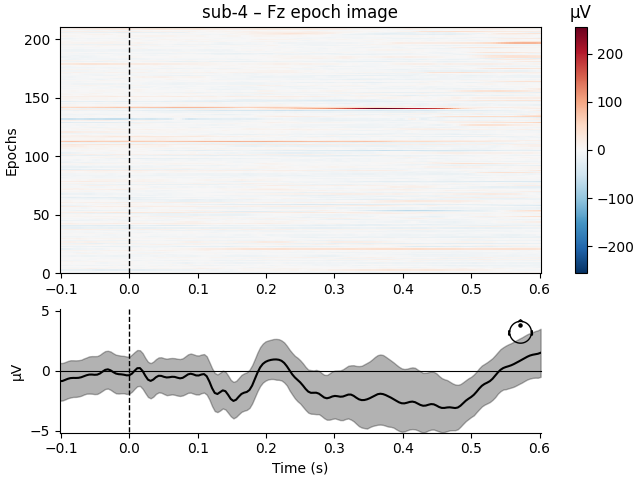

In [315]:
# Each row = one epoch, colour = amplitude at channel Fz
plt.close('all')
epochs.plot_image(picks=['Fz'], title=f'{sub_id} – Fz epoch image');

---
## Part 5 · Baseline Correction

### 📌 Task 5.1 – Apply baseline correction

In [316]:
# ── 6. Baseline Correction (−100 to 0 ms) ────────────────────────────────────
epochs.apply_baseline(baseline=(-0.1, 0))

<Epochs | 211 events (all good), -0.102 – 0.602 s (baseline -0.1 – 0 s), ~18.4 MiB, data loaded,
 'Go/1': 54
 'Go/2': 52
 'Go/3': 52
 'NoGo': 53>

### 📌 Task 5.2 – Verify the baseline correction

In [317]:
# Sanity check: mean amplitude in the baseline window should be ≈ 0
baseline_check = epochs.copy().crop(tmin=-0.1, tmax=0)
mean_uv = baseline_check.get_data().mean() * 1e6
print(f'Mean amplitude in baseline window: {mean_uv:.6f} µV  (should be ≈ 0)')

Mean amplitude in baseline window: -0.080751 µV  (should be ≈ 0)


---
## Part 6 · Epoch Rejection

### 📌 Task 6.1 – Reject bad epochs

In [318]:
# Epoch Rejection (amplitude threshold)
# 200 µV threshold (slightly looser than standard 150 µV for this dataset)
reject_criteria = {'eeg': 200e-6}

n_before = len(epochs)
epochs.drop_bad(reject=reject_criteria)
n_after  = len(epochs)

print(f'Epochs before rejection: {n_before}')
print(f'Epochs after  rejection: {n_after}')
print(f'Rejected: {n_before - n_after} ({(n_before - n_after) / n_before * 100:.1f}%)')

Epochs before rejection: 211
Epochs after  rejection: 203
Rejected: 8 (3.8%)


### 📌 Task 6.2 – Plot the drop log

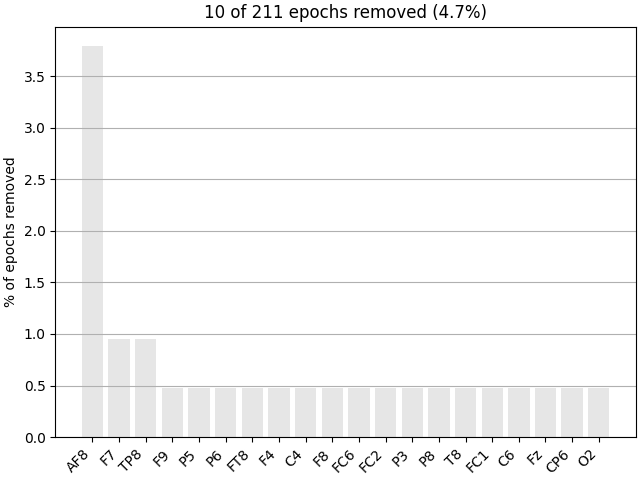

In [301]:
epochs.plot_drop_log();

---
## Part 7 · Save

### 📌 Task 7.1 – Print summary

In [319]:
# Summary & Save 
print('=' * 55)
print(f'  Summary for {sub_id}')
print('=' * 55)
print(f'  Clean epochs total:     {len(epochs)}')
print(f'  Conditions:             {list(epochs.event_id.keys())}')
print(f'  Time window:            {epochs.tmin*1000:.0f} to {epochs.tmax*1000:.0f} ms')
print(f'  Sampling rate:          {epochs.info["sfreq"]} Hz')
print(f'  ICA components removed: {bad_components}')
print('=' * 55)
for cond in epochs.event_id:
    print(f'  {cond:6s}: {len(epochs[cond])} epochs')

  Summary for sub-4
  Clean epochs total:     203
  Conditions:             ['Go/1', 'Go/2', 'Go/3', 'NoGo']
  Time window:            -102 to 602 ms
  Sampling rate:          256.0 Hz
  ICA components removed: [6]
  Go/1  : 52 epochs
  Go/2  : 50 epochs
  Go/3  : 50 epochs
  NoGo  : 51 epochs


### 📌 Task 7.2 – Save the clean epochs

In [320]:
out_path = op.join(DATA_DIR_ORIG, f'{sub_id}_day2_task-gonogo_epo.fif')
epochs.save(out_path, overwrite=True)
print(f'Saved: {out_path}')


Saved: ../data/hackathon_data/sub-4/eeg\sub-4_day2_task-gonogo_epo.fif
